In [14]:
import sys
sys.path.insert(0, "..")

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json

from experiments._analysis import setup_matplotlib

setup_matplotlib()

THRESHOLD = 0.015
NUM_BINS = 100

In [15]:
udacity_image_root = Path("../dataset/udacity/images")
udacity_labels_path = Path("../dataset/udacity/labels_train.csv")


def parse_int(value):
    try:
        return int(round(float(value)))
    except (TypeError, ValueError):
        return None


def normalize_box(row):
    xmin = parse_int(row.get("xmin") or row.get("x1"))
    ymin = parse_int(row.get("ymin") or row.get("y1"))
    xmax = parse_int(row.get("xmax") or row.get("x2"))
    ymax = parse_int(row.get("ymax") or row.get("y2"))

    if None in (xmin, ymin, xmax, ymax):
        return None

    if xmax <= xmin or ymax <= ymin:
        return None

    return xmin, ymin, xmax, ymax


image_lookup = {
    path.name: path
    for path in udacity_image_root.rglob("*")
    if path.is_file()
}

bbox_area_fractions = []

with open(udacity_labels_path, encoding="utf-8", newline="") as handle:
    reader = csv.DictReader(handle)

    for row in reader:
        image_name = str(
            row.get("frame")
            or row.get("image")
            or row.get("filename")
            or ""
        ).strip()

        image_path = image_lookup.get(Path(image_name).name)
        box = normalize_box(row)

        if image_path is None or box is None:
            continue

        with Image.open(image_path) as image:
            width, height = image.size

        image_area = width * height
        if image_area <= 0:
            continue

        xmin, ymin, xmax, ymax = box
        bbox_area = (xmax - xmin) * (ymax - ymin)
        area_fraction = bbox_area / image_area

        if 0 <= area_fraction <= 1:
            bbox_area_fractions.append(area_fraction)

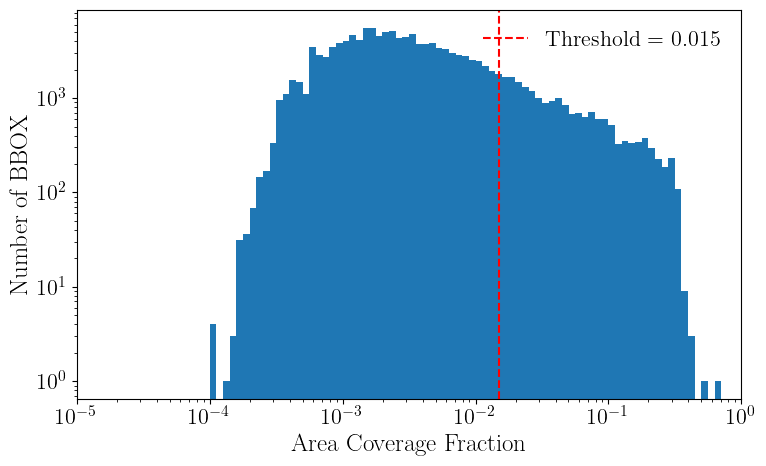

In [20]:
bins = np.logspace(-5, 0, NUM_BINS + 1)

plt.figure(figsize=(8, 5))

plt.hist(
    bbox_area_fractions,
    bins=bins,
    log=True,          # logarithmic y-axis
)

plt.xscale("log")      # logarithmic x-axis

plt.axvline(
    0.015,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Threshold = 0.015",
)

plt.xlim(1e-4, 1)
plt.xlabel("Area Coverage Fraction")
plt.ylabel("Number of BBOX")
plt.legend()
plt.savefig("udacity_bbox_frac.pdf", dpi=200, bbox_inches="tight")

In [22]:
selection_root = Path("../defaults/mmm/results/selection")

imagenet_dirs = [
    selection_root / "single" / "solo",
    selection_root / "single" / "multi",
    selection_root / "multi",
]


def bbox_area(box):
    return (
        (box["xmax"] - box["xmin"])
        * (box["ymax"] - box["ymin"])
    )


bbox_area_fractions = []

for base_dir in imagenet_dirs:
    for json_path in base_dir.rglob("original.json"):
        with open(json_path, encoding="utf-8") as file:
            sample = json.load(file)

        width, height = sample["original_dims"]
        image_area = width * height

        if image_area <= 0:
            continue

        for box in sample.get("ground_truth", {}).values():
            area_fraction = bbox_area(box) / image_area

            if 0 < area_fraction <= 1:
                bbox_area_fractions.append(area_fraction)

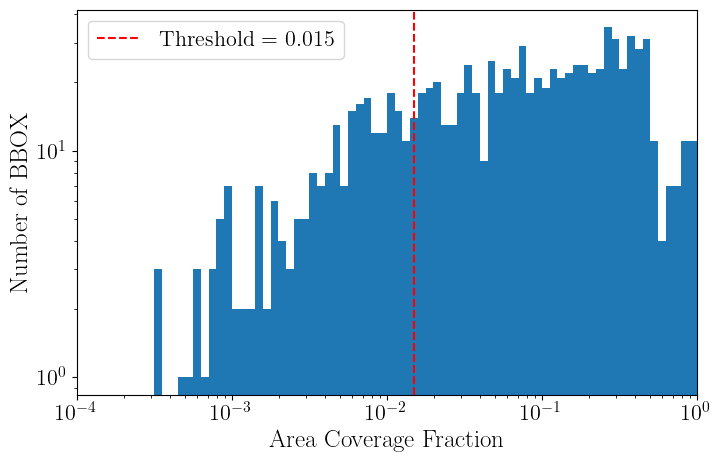

In [23]:
bins = np.logspace(-5, 0, NUM_BINS + 1)

plt.figure(figsize=(8, 5))

plt.hist(
    bbox_area_fractions,
    bins=bins,
)

plt.xscale("log")
plt.yscale("log")

plt.axvline(
    THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold = {THRESHOLD:.3f}",
)

plt.xlim(1e-4, 1)
plt.xlabel("Area Coverage Fraction")
plt.ylabel("Number of BBOX")
plt.legend()
plt.savefig("figures/im_bbox_frac.pdf", dpi=200, bbox_inches="tight")